In [2]:
%reload_ext autoreload

import os 
import pandas as pd 
import tensorflow as tf 
import plotly.express as px

from utils import (show_class_distribution, fix_images, 
                   get_files_by_class , plot_class_distribution , 
                   create_train_test_val_split, compute_class_weights_from_directory, evaluate_binary_model, show_samples_per_class, sanity_check_labels,
                    get_true_and_proba , scan_thresholds)
import matplotlib.pyplot as plt
import numpy as np

2026-02-22 19:17:51.487811: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-22 19:17:51.975914: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 19:17:53.452058: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## EDA

We will begin by fixing the images and make sure we are removing any image not compatible with TensorFlow.

In [3]:
ROOT_DIR = "./data"
DATA_DIR = f"{ROOT_DIR}/data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
LEARNING_RATE = 3e-4
EPOCHS = 10

In [4]:
show_class_distribution(DATA_DIR)

Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 3725
Class: Samples - Number of samples: 8
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 1905


In [5]:
fix_images(DATA_DIR)

Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/422_10000_6200_img_8UXGVkszCbidTR49_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2857_9000_11200_img_NgkRiqvlSMUKRxSO_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_CFAY073B8sznfZJG_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2_400_0_img_0t9JBHeOeBHgaLmJ_JAV_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2690_2600_9400_img_8jmWSIh9LhIh4p4e_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/15_600_600_img_yypoVwlHZPchMcLa_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/1064_9200_7400_img_xCVKEyUQBMP2ef8r_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/460_5400_3000_img_lHgjbs0x2eQq1CKp_GBR_cls_0.jpg of type: jpeg
Accepted file: data/

In [6]:
show_class_distribution(DATA_DIR)

Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 3725
Class: Samples - Number of samples: 8
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 1905


In [7]:
plot_class_distribution(DATA_DIR)

We can observe that we have an unbalanced dataset , which will require data augmentation.

**TRAIN / TEST / VAL Split**

In [8]:
create_train_test_val_split(
    DATA_DIR,
    allowed_classes=[
        "S1SAR_UnBalanced_400by400_Class_0",
        "S1SAR_UnBalanced_400by400_Class_1"
    ]
)


Skipping class: Samples as it's not in allowed_classes
Dataset split completed. Organized data saved to: data/organized


In [9]:
plot_class_distribution("data/organized")

In [10]:
plot_class_distribution("data/organized/train")

In [11]:
plot_class_distribution("data/organized/test")

In [12]:
plot_class_distribution("data/organized/val")

**LOADING DATASETS WITH KERAS**

In [13]:
tf.random.set_seed(SEED)

In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{ROOT_DIR}/organized/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{ROOT_DIR}/organized/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{ROOT_DIR}/organized/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 3940 files belonging to 2 classes.


I0000 00:00:1771784278.391037    8408 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12125 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9


Found 845 files belonging to 2 classes.
Found 845 files belonging to 2 classes.


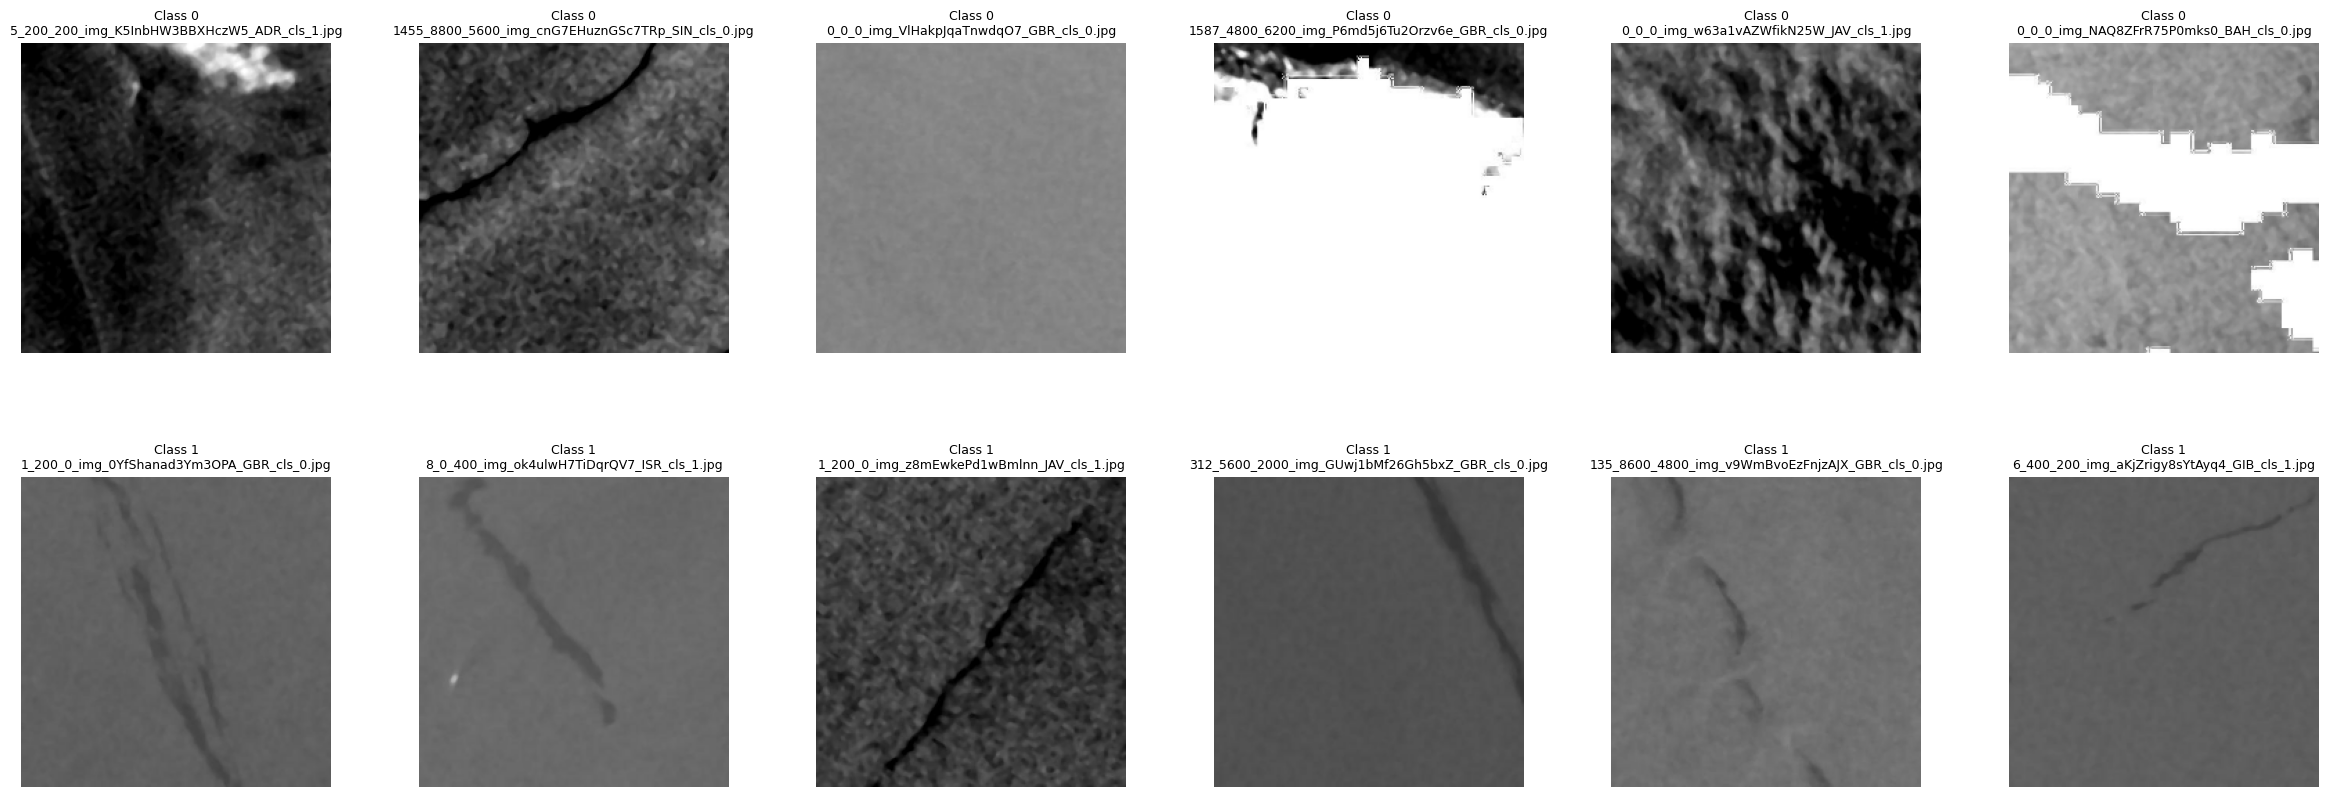

In [18]:
show_samples_per_class(train_ds)


In [16]:
sanity_check_labels(train_ds, DATA_DIR)

✅ Sanity check passed. All files match expected class folders.


In [17]:
# This will optimize the dataset for performance by prefetching data while the model is training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

We compute the class weights to handle the unbalanced dataset

In [18]:
class_weight = compute_class_weights_from_directory(f"{ROOT_DIR}/organized/train")
print(class_weight)

{0: 0.7556578442654392, 1: 1.4778694673668418}


Data augmentation is applied exclusively to the training set.
Given the radar-specific nature of Sentinel-1 SAR imagery, augmentations are kept conservative to avoid altering the physical properties of the signal.

In [19]:
data_ag = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
])

# TRAINING

**BASELINE MODEL**  
A simple CNN to start with.

In [20]:
model = tf.keras.Sequential([
    data_ag,
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32,3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3, padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [23]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    # class_weight=class_weight,
    callbacks=[early_stopping]
)

Epoch 1/10


2026-02-19 04:14:08.634755: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6480 - loss: 1.5812 - val_accuracy: 0.3385 - val_loss: 0.7601
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6622 - loss: 0.6351 - val_accuracy: 0.6615 - val_loss: 0.6712
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6617 - loss: 0.6283 - val_accuracy: 0.6615 - val_loss: 0.6533
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6617 - loss: 0.6245 - val_accuracy: 0.6615 - val_loss: 0.6524
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6617 - loss: 0.6152 - val_accuracy: 0.6615 - val_loss: 0.6081
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6617 - loss: 0.6294 - val_accuracy: 0.6615 - val_loss: 0.6177
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6617 - loss: 0.6243 - val_accuracy: 0.6615 - val_loss: 0.6109
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6617 - loss: 0.6211 - val_accuracy: 0.66

In [24]:
model.evaluate(test_ds)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6615 - loss: 0.5768


[0.5768436193466187, 0.6615384817123413]

In [25]:
y_true, y_pred = evaluate_binary_model(model, test_ds);

True distribution: [559 286]
Predicted distribution: [845]

Confusion Matrix:
[[559   0]
 [286   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      1.00      0.80       559
           1       0.00      0.00      0.00       286

    accuracy                           0.66       845
   macro avg       0.33      0.50      0.40       845
weighted avg       0.44      0.66      0.53       845



2026-02-19 04:15:10.790023: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/andrealoy/Documents/repos/sentinel-1-oil-detection/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/andrealoy/Documents/repos/sentinel-1-oil-detection/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/andrealoy/Documents/repos/sentinel-1-oil-detection/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_

Here , we can see that the model doesn't converge very much with an accuracy at 72%.

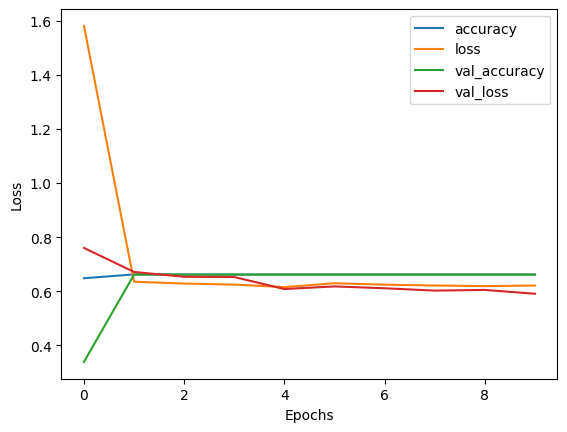

In [26]:
pd.DataFrame(history.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [27]:
def build_improved_cnn(input_shape=(224,224,3)):

    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Rescaling(1./255)(inputs)

    # Bloc 1
    x = tf.keras.layers.Conv2D(32, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Bloc 2
    x = tf.keras.layers.Conv2D(64, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Bloc 3
    x = tf.keras.layers.Conv2D(128, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Bloc 4 (nouveau)
    x = tf.keras.layers.Conv2D(256, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)

    return model


In [28]:
model_improved = build_improved_cnn()

model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC(name="auc")
    ]
)
history_improved = model_improved.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    # class_weight=class_weight,
    callbacks=[early_stopping]
)

Epoch 1/10


2026-02-19 04:15:12.212732: I external/local_xla/xla/service/service.cc:163] XLA service 0x718ca0033030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-19 04:15:12.212757: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 SUPER, Compute Capability 8.9
2026-02-19 04:15:12.252631: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-19 04:15:12.564172: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-19 04:15:12.564188: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none

  7/124 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5757 - auc: 0.6072 - loss: 0.7555 - precision: 0.3395 - recall: 0.7185

I0000 00:00:1771470916.085095  543903 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.7140 - auc: 0.7232 - loss: 0.5829 - precision: 0.6006 - recall: 0.4614 - val_accuracy: 0.3385 - val_auc: 0.6280 - val_loss: 0.8420 - val_precision: 0.3385 - val_recall: 1.0000
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7338 - auc: 0.7635 - loss: 0.5416 - precision: 0.6514 - recall: 0.4584 - val_accuracy: 0.4107 - val_auc: 0.6284 - val_loss: 0.7770 - val_precision: 0.3540 - val_recall: 0.8986
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7426 - auc: 0.7851 - loss: 0.5232 - precision: 0.6562 - recall: 0.5026 - val_accuracy: 0.4970 - val_auc: 0.6972 - val_loss: 0.7303 - val_precision: 0.3866 - val_recall: 0.8287
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7566 - auc: 0.8013 - loss: 0.5074 - precision: 0.6767 - recall: 0.5371 - val_accuracy: 0.6876 - val_auc: 0.7483 - val_loss: 0.6079 - val_precision: 0.5288 - val_recall: 0.7063
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━

In [29]:
model_improved.evaluate(test_ds)
evaluate_binary_model(model_improved, test_ds);

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7775 - auc: 0.8260 - loss: 0.4968 - precision: 0.6541 - recall: 0.7273
True distribution: [559 286]
Predicted distribution: [527 318]

Confusion Matrix:
[[449 110]
 [ 78 208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.83       559
           1       0.65      0.73      0.69       286

    accuracy                           0.78       845
   macro avg       0.75      0.77      0.76       845
weighted avg       0.79      0.78      0.78       845



2026-02-19 04:15:52.584278: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [30]:
y_val_true, y_val_proba = get_true_and_proba(model_improved, val_ds)
results = scan_thresholds(y_val_true, y_val_proba)

threshold | precision | recall | f1
------------------------------------
    0.10 |     0.393 |  0.979 |  0.561
    0.15 |     0.407 |  0.951 |  0.570
    0.20 |     0.429 |  0.937 |  0.589
    0.25 |     0.462 |  0.906 |  0.612
    0.30 |     0.489 |  0.864 |  0.625
    0.35 |     0.521 |  0.822 |  0.638
    0.40 |     0.551 |  0.794 |  0.650
    0.45 |     0.588 |  0.759 |  0.663
    0.50 |     0.607 |  0.724 |  0.660
    0.55 |     0.642 |  0.696 |  0.668
    0.60 |     0.668 |  0.647 |  0.657
    0.65 |     0.706 |  0.570 |  0.631
    0.70 |     0.704 |  0.483 |  0.573
    0.75 |     0.726 |  0.399 |  0.515
    0.80 |     0.813 |  0.304 |  0.443
    0.85 |     1.000 |  0.122 |  0.218


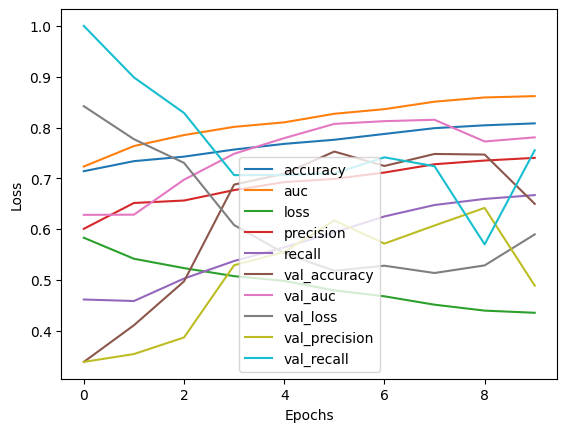

In [31]:
pd.DataFrame(history_improved.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [37]:
def build_efficientnet(input_shape=(224,224,3)):
    # EfficientNetB0 s'attend à des inputs entre [0, 255] par défaut dans Keras
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    base_model.trainable = False 

    inputs = tf.keras.Input(shape=input_shape)

    # --- CORRECTION ICI : ON RETIRE LE RESCALING ---
    # On passe directement les inputs au base_model
    # EfficientNet s'occupe de la normalisation en interne
    x = base_model(inputs, training=False) 

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)

    return model

In [38]:
efficient_net_model = build_efficientnet()

efficient_net_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

history_efficient_net = efficient_net_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    # class_weight=class_weight,
    callbacks=[early_stopping]
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.7183 - loss: 0.5599 - precision_2: 0.6939 - recall_2: 0.2993 - val_accuracy: 0.8426 - val_loss: 0.4583 - val_precision_2: 0.9371 - val_recall_2: 0.5734
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8317 - loss: 0.4338 - precision_2: 0.8587 - recall_2: 0.6017 - val_accuracy: 0.8876 - val_loss: 0.3753 - val_precision_2: 0.9244 - val_recall_2: 0.7273
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8726 - loss: 0.3640 - precision_2: 0.8726 - recall_2: 0.7299 - val_accuracy: 0.8923 - val_loss: 0.3322 - val_precision_2: 0.9079 - val_recall_2: 0.7587
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8764 - loss: 0.3369 - precision_2: 0.8704 - recall_2: 0.7457 - val_accuracy: 0.8970 - val_loss: 0.3066 - val_precision_2: 0.8933 - val_recall_2: 0.7902
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8838 - loss: 0.3156 - precision_2: 0.8711 - recall_2: 0.

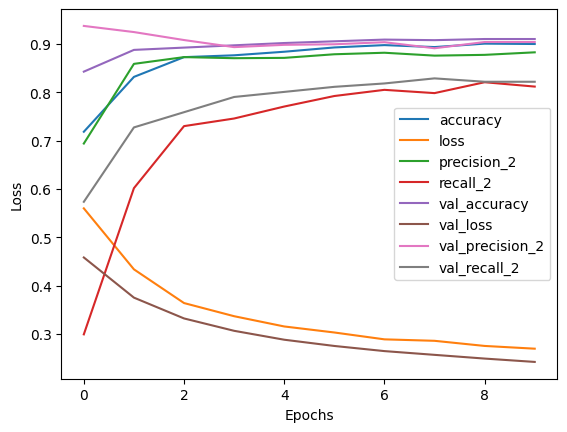

In [39]:
pd.DataFrame(history_efficient_net.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [40]:
efficient_net_model.evaluate(test_ds)
evaluate_binary_model(efficient_net_model, test_ds);

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9006 - loss: 0.2683 - precision_2: 0.8915 - recall_2: 0.8042
True distribution: [559 286]
Predicted distribution: [587 258]

Confusion Matrix:
[[531  28]
 [ 56 230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       559
           1       0.89      0.80      0.85       286

    accuracy                           0.90       845
   macro avg       0.90      0.88      0.89       845
weighted avg       0.90      0.90      0.90       845



In [41]:
# 1. Dégeler le modèle de base
efficient_net_model.trainable = True

# 2. On veut affiner, pas tout casser. On ne garde que les 20 dernières couches entraînables.
# EfficientNetB0 a environ 230 couches.
for layer in efficient_net_model.layers[:-20]:
    layer.trainable = False

# 3. COMPILATION CRITIQUE : Il faut un Learning Rate très bas (10x ou 100x plus petit)
# Si vous gardez 3e-4, vous allez détruire les poids actuels.
efficient_net_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Notez le 1e-5
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# 4. On relance l'entraînement pour quelques epochs (Fine-tuning)
history_fine = efficient_net_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # Souvent 5-10 suffisent
    class_weight=class_weight, # Toujours garder les poids !
    callbacks=[early_stopping]
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - accuracy: 0.9018 - loss: 0.2988 - precision_3: 0.8695 - recall_3: 0.8350 - val_accuracy: 0.9136 - val_loss: 0.2430 - val_precision_3: 0.9019 - val_recall_3: 0.8357
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9058 - loss: 0.2885 - precision_3: 0.8694 - recall_3: 0.8492 - val_accuracy: 0.9124 - val_loss: 0.2440 - val_precision_3: 0.8926 - val_recall_3: 0.8427
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9030 - loss: 0.2867 - precision_3: 0.8644 - recall_3: 0.8462 - val_accuracy: 0.9101 - val_loss: 0.2454 - val_precision_3: 0.8777 - val_recall_3: 0.8531
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9066 - loss: 0.2882 - precision_3: 0.8669 - recall_3: 0.8552 - val_accuracy: 0.9124 - val_loss: 0.2469 - val_precision_3: 0.8759 - val_recall_3: 0.8636
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9058 - loss: 0.2839 - precision_3: 0.8547 - recall_3: 0.

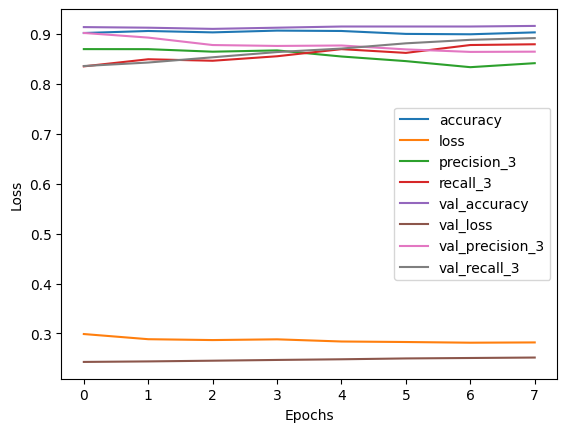

In [42]:
pd.DataFrame(history_fine.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [44]:
efficient_net_model.evaluate(test_ds)
evaluate_binary_model(efficient_net_model, test_ds);

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9041 - loss: 0.2680 - precision_3: 0.8897 - recall_3: 0.8182
True distribution: [559 286]
Predicted distribution: [582 263]

Confusion Matrix:
[[530  29]
 [ 52 234]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       559
           1       0.89      0.82      0.85       286

    accuracy                           0.90       845
   macro avg       0.90      0.88      0.89       845
weighted avg       0.90      0.90      0.90       845



In [ ]:
efficient_net_model.evaluate(test_ds)
evaluate_binary_model(efficient_net_model, test_ds);

Extraction des images et prédictions...


2026-02-19 04:35:23.447831: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total Faux Positifs : 29
Total Faux Négatifs : 52


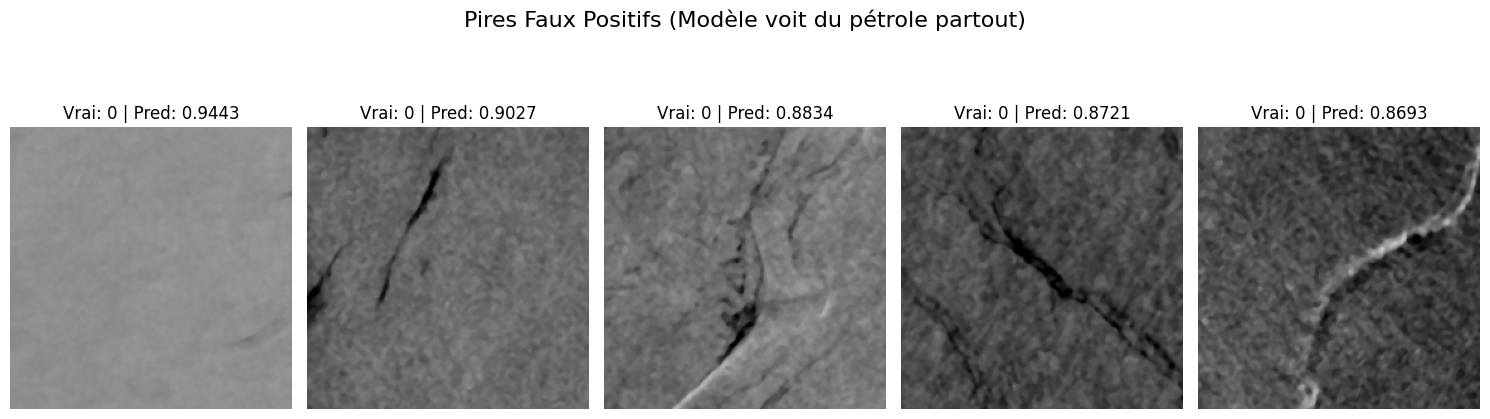

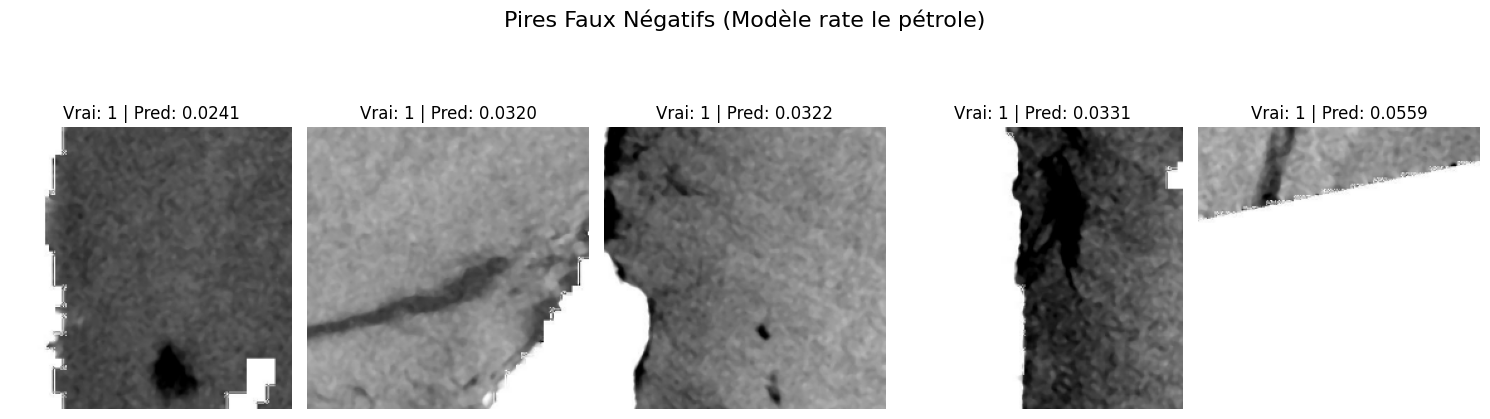

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def visualize_worst_errors(model, dataset, num_images=5):
    # 1. Extraire toutes les images et labels du dataset de test
    # (Attention : cela charge tout le dataset de test en RAM, 
    # c'est ok pour 845 images, mais attention si vous aviez 100k images)
    print("Extraction des images et prédictions...")
    images = []
    labels = []
    
    for img_batch, label_batch in dataset:
        images.append(img_batch.numpy())
        labels.append(label_batch.numpy())
        
    X_test = np.concatenate(images)
    y_true = np.concatenate(labels)
    
    # 2. Faire les prédictions
    # On prédit sur le tableau numpy pour être sûr de l'ordre
    y_pred_probs = model.predict(X_test, verbose=0).flatten()
    
    # 3. Identifier les erreurs
    # Seuil standard de 0.5 pour définir l'erreur
    y_pred_binary = (y_pred_probs > 0.5).astype(int)
    
    # Indices des erreurs
    fp_indices = np.where((y_true == 0) & (y_pred_binary == 1))[0] # Faux Positifs
    fn_indices = np.where((y_true == 1) & (y_pred_binary == 0))[0] # Faux Négatifs
    
    print(f"Total Faux Positifs : {len(fp_indices)}")
    print(f"Total Faux Négatifs : {len(fn_indices)}")
    
    # 4. Trier par "gravité" (Confiance du modèle)
    # Pires FP : Le modèle a prédit une proba proche de 1.0 (très sûr de lui) alors que c'est 0
    worst_fp = fp_indices[np.argsort(y_pred_probs[fp_indices])[::-1][:num_images]]
    
    # Pires FN : Le modèle a prédit une proba proche de 0.0 (très sûr de lui) alors que c'est 1
    worst_fn = fn_indices[np.argsort(y_pred_probs[fn_indices])[:num_images]]
    
    # 5. Fonction d'affichage
    def plot_images(indices, title_prefix):
        if len(indices) == 0:
            print(f"Pas d'erreurs trouvées pour : {title_prefix}")
            return
            
        plt.figure(figsize=(15, 5))
        for i, idx in enumerate(indices):
            plt.subplot(1, num_images, i + 1)
            
            # Gestion de l'affichage (uint8 vs float)
            img = X_test[idx]
            if img.max() > 1.0:
                img = img.astype("uint8")
            
            plt.imshow(img)
            plt.title(f"Vrai: {y_true[idx]} | Pred: {y_pred_probs[idx]:.4f}")
            plt.axis("off")
        plt.suptitle(title_prefix, fontsize=16)
        plt.tight_layout()
        plt.show()

    # Afficher
    plot_images(worst_fp, "Pires Faux Positifs (Modèle voit du pétrole partout)")
    plot_images(worst_fn, "Pires Faux Négatifs (Modèle rate le pétrole)")

# Lancer la visualisation
visualize_worst_errors(efficient_net_model, test_ds)

In [47]:
import os
import cv2
import numpy as np
from pathlib import Path

def find_corrupted_images(data_dir, threshold_black_percent=0.10):
    """
    Identifie les images qui ont trop de pixels noirs (bords/masques).
    threshold_black_percent : Si plus de 10% de l'image est noir pur (0), on la flag.
    """
    bad_images = []
    
    # Parcourir récursivement
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(root, file)
                
                # Lire l'image en gris
                img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                
                if img is None:
                    continue
                
                # Compter les pixels noirs (valeur proche de 0)
                # On met < 5 car parfois la compression JPG fait que le noir n'est pas exactement 0
                black_pixels = np.sum(img < 5)
                total_pixels = img.size
                ratio = black_pixels / total_pixels
                
                if ratio > threshold_black_percent:
                    bad_images.append((filepath, ratio))

    return bad_images

# Utilisation
ROOT_DIR = "./data/organized" # Ton dossier de train/val/test
bad_imgs = find_corrupted_images(ROOT_DIR)

print(f"Images problématiques trouvées : {len(bad_imgs)}")

# Afficher quelques exemples pour vérifier avant de supprimer
for path, ratio in bad_imgs[:5]:
    print(f"{path} -> {ratio*100:.2f}% de noir")

# Si tu es confiant, tu peux décommenter ceci pour les supprimer (ou les déplacer)
# for path, _ in bad_imgs:
#     os.remove(path)

Images problématiques trouvées : 98
./data/organized/train/S1SAR_UnBalanced_400by400_Class_0/460_5400_3000_img_lHgjbs0x2eQq1CKp_GBR_cls_0.jpg -> 27.59% de noir
./data/organized/train/S1SAR_UnBalanced_400by400_Class_0/39_3000_600_img_JkLqOgrRUbExe4fW_GBR_cls_0.jpg -> 10.29% de noir
./data/organized/train/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg -> 61.09% de noir
./data/organized/train/S1SAR_UnBalanced_400by400_Class_0/1019_12400_4000_img_2A8VePMGEX2nNmAa_GBR_cls_0.jpg -> 62.95% de noir
./data/organized/train/S1SAR_UnBalanced_400by400_Class_0/1586_4600_6200_img_03Q3PAMUQOZKM0H5_GBR_cls_0.jpg -> 45.77% de noir
